# Circuitos Quânticos 3
Códigos utilizados na Seção `Circuitos Quânticos III` dos slides.

**Objetivos**
- Utilização do `AerSimulator` e `SamplerV2`
- Execução de circuitos nos computadores da IBM

## Conexão com IBM Quantum Platform

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel='ibm_quantum',
    instance='ibm-q/open/main',
    token='TOKEN HERE'
)

# Or save your credentials on disk.
# QiskitRuntimeService.save_account(channel='ibm_quantum', instance='ibm-q/open/main', token='9c65f024a3995393e34c63ea655372928d020303e9fbbe1e6bc8217d216eaeaebd3d162aa119d42b743514ecf229c20995c76480757d49ff6b6809879a7cfa80')

In [11]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2, EstimatorV2, QiskitRuntimeService
from qiskit.circuit import Parameter
from qiskit.visualization import plot_distribution, plot_histogram
import numpy as np

## Verificação de Computadores Disponíveis

In [5]:
# verificar computadores quânticos disponíveis
QiskitRuntimeService().backends(simulator=False, operational=True)

[<IBMBackend('ibm_kyiv')>,
 <IBMBackend('ibm_brisbane')>,
 <IBMBackend('ibm_sherbrooke')>]

In [6]:
# listar os computadores quânticos menos ocupados
QiskitRuntimeService().least_busy(operational=True)

<IBMBackend('ibm_brisbane')>

## Preparação de Backends

In [9]:
# backend simulado
backend_aer = AerSimulator()

# backend real
backend_ibm = QiskitRuntimeService().backend('ibm_brisbane')  

## Circuito Normal (qc1)

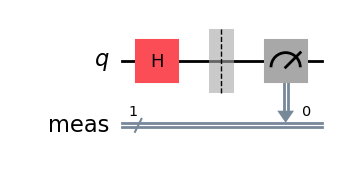

In [10]:
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.measure_all() # o estimator precisa do 'meas'
qc1.draw('mpl')

## Circuito Parametrizado (qc2)

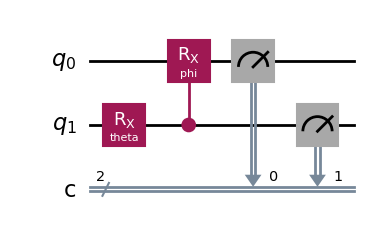

In [19]:
th = Parameter('theta')  # parâmetro
ph = Parameter('phi')    # parâmetro

qubits = QuantumRegister(2,'q')
cbits = ClassicalRegister(2,'c')

qc2 = QuantumCircuit(qubits, cbits)
qc2.rx(th,1)
qc2.crx(ph,1,0)

qc2.measure(qubits, cbits)
qc2.draw('mpl')

In [14]:
# lista de parâmetros
angles = [ [np.pi/4,np.pi/2] , [np.pi/3,np.pi] , [np.pi/2,np.pi] ]

In [20]:
qc2.parameters  # mostra a ordem dos parâmetros

ParameterView([Parameter(phi), Parameter(theta)])

## Transpilação dos Circuitos

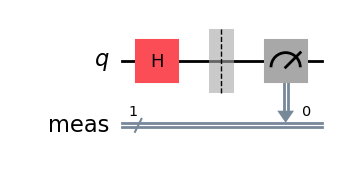

In [57]:
# AerSimulator QC1
qc1_aer = transpile(qc1, backend=backend_aer)
qc1_aer.draw('mpl')

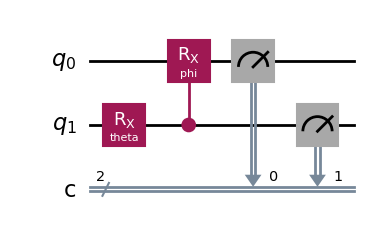

In [97]:
# AerSimulator QC2
qc2_aer = transpile(qc2, backend=backend_aer)
qc2_aer.draw('mpl', idle_wires=False)

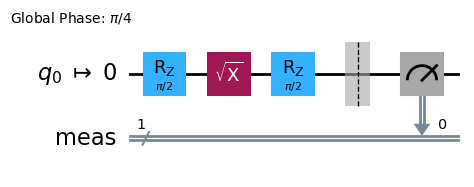

In [61]:
# IBM QC1
qc1_ibm = transpile(qc1, backend=backend_ibm)
qc1_ibm.draw('mpl', idle_wires=False)

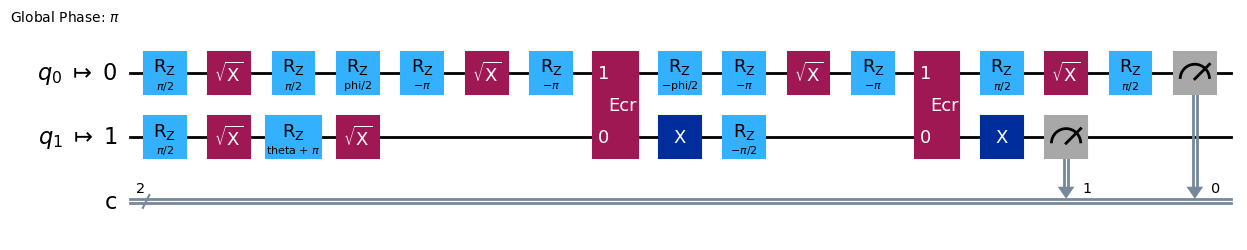

In [62]:
# IBM QC2
qc2_ibm = transpile(qc2, backend=backend_ibm)
qc2_ibm.draw('mpl', idle_wires=False)

## Executando os Circuitos

In [99]:
# SamplerV2: permite a eficiência na execução nos computadores quânticos e potencializa funcionalidades com o AerSimulator)
sampler_aer = SamplerV2(mode=backend_aer)
sampler_ibm = SamplerV2(mode=backend_ibm)

In [69]:
# Execução do circuito no AerSimulator
job_aer = sampler_aer.run( [(qc1_aer,None,100) , (qc2_aer, angles, 1000)] )  # (circuit, parameters, shots)

In [83]:
# Execução do circuito no computador quântico da IBM
# acessar https://quantum.ibm.com/ e verificar o status do processamento
# job_ibm = sampler_ibm.run( [(qc1_ibm,None,100) , (qc2_ibm, angles, 1000)] )  # <<< DESCOMENTAR

In [75]:
# Obtém o resultado do job
job = service.job('cyqr6kty9d800086npt0')
job_result = job.result()
job_result

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=100, num_bits=1>)), metadata={'circuit_metadata': {}}), SamplerPubResult(data=DataBin(c=BitArray(<shape=(3,), num_shots=1000, num_bits=2>), shape=(3,)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([{'__type__': 'DoubleSliceSpan', '__value__': {'start': datetime.datetime(2025, 2, 14, 18, 11, 48, 706790), 'stop': datetime.datetime(2025, 2, 14, 18, 11, 50, 549648), 'data_slices': {'0': [[100], 0, 1, 0, 100]}}}, {'__type__': 'DoubleSliceSpan', '__value__': {'start': datetime.datetime(2025, 2, 14, 18, 11, 52, 279847), 'stop': datetime.datetime(2025, 2, 14, 18, 11, 55, 86488), 'data_slices': {'1': [[3, 1000], 0, 3, 0, 1000]}}}])}, 'version': 2})

In [93]:
# Resultados dos circuitos
result_aer = job_aer.result()  # retorna os resultados do qc1 e qc2 a partir do AerSimulator
result_ibm = job_ibm.result()  # retorna os resultados do qc1 e qc2 a partir do computador da IBM

In [91]:
# Obtendo os resultados do circuito simples qc1
counts_qc1_aer = result_aer[0].data.meas.get_counts()
counts_qc1_ibm = result_ibm[0].data.meas.get_counts()

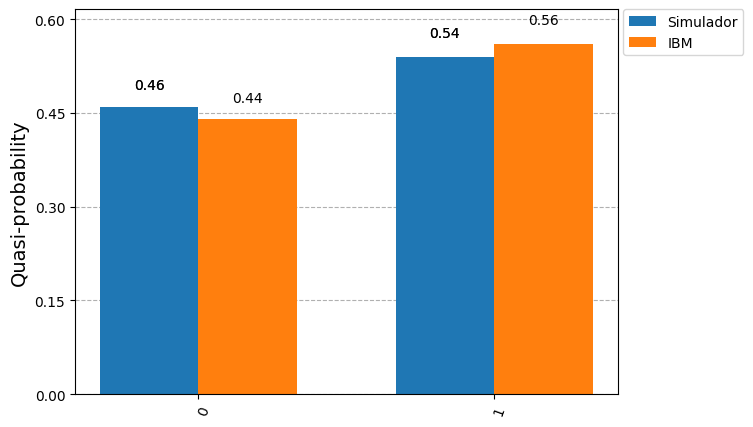

In [94]:
plot_distribution( [counts_qc1_aer, counts_qc1_ibm] , legend=['Simulador', 'IBM'])

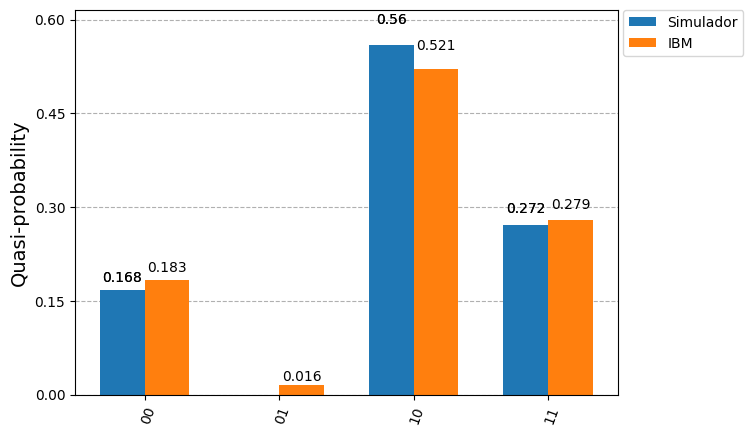

In [96]:
# Obtendo os resultados do circuito parametrizado qc2 (considerando todos parâmetros)
counts_qc2_aer = result_aer[1].data.c.get_counts()
counts_qc2_ibm = result_ibm[1].data.c.get_counts()

plot_distribution( [counts_qc2_aer, counts_qc2_ibm] , legend=['Simulador', 'IBM'])

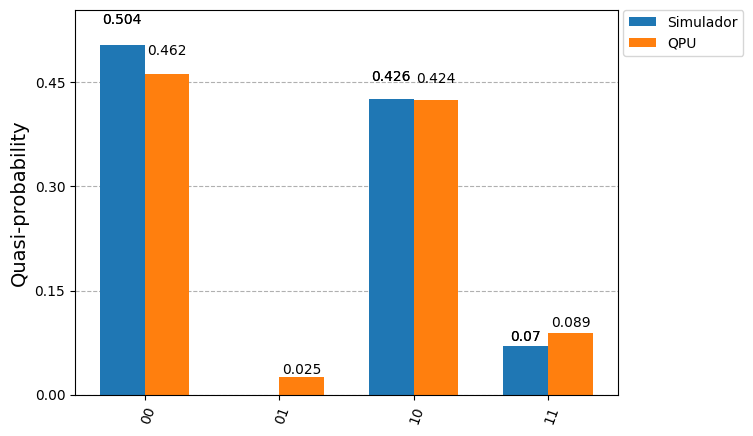

In [87]:
# Obtendo os resultados do circuito parametrizado qc2 conforme parâmetros definidos na variável angles
counts_qc2_aer = result_aer[1].data.c.get_counts(0)  # 1º parâmetro
counts_qc2_ibm = result_ibm[1].data.c.get_counts(0)  # 1º parâmetro

plot_distribution( [counts_qc2_aer, counts_qc2_ibm] , legend=['Simulador', 'IBM'])

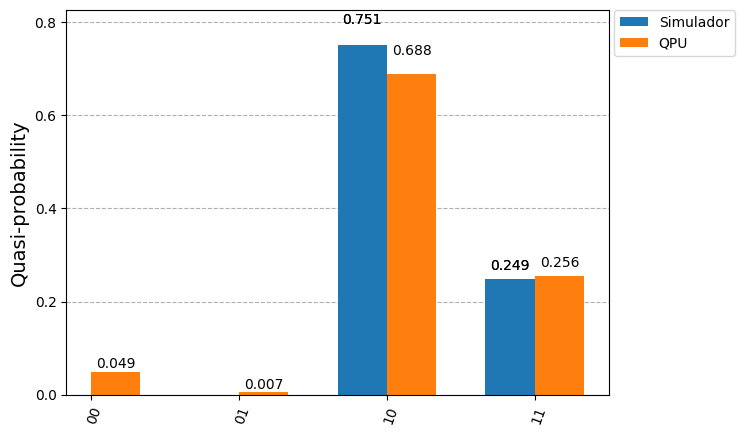

In [88]:
# Obtendo os resultados do circuito parametrizado qc2 conforme parâmetros definidos na variável angles
counts_qc2_aer = result_aer[1].data.c.get_counts(1)  # 2º parâmetro
counts_qc2_ibm = result_ibm[1].data.c.get_counts(1)  # 2º parâmetro

plot_distribution( [counts_qc2_aer, counts_qc2_ibm] , legend=['Simulador', 'IBM'])

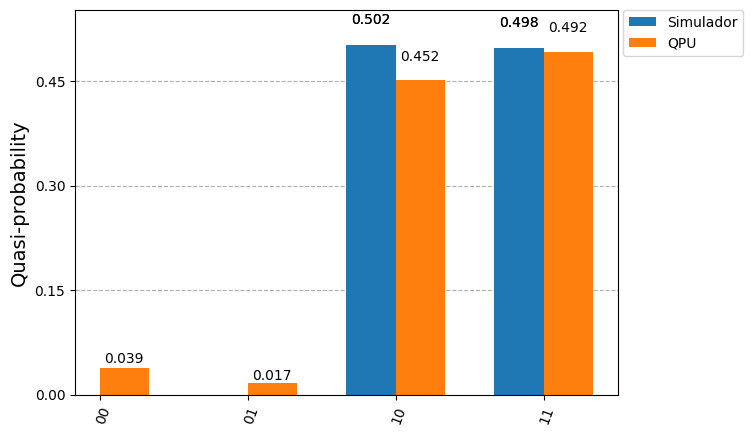

In [90]:
# Obtendo os resultados do circuito parametrizado qc2 conforme parâmetros definidos na variável angles
counts_qc2_aer = result_aer[1].data.c.get_counts(2)  # 3º parâmetro
counts_qc2_ibm = result_ibm[1].data.c.get_counts(2)  # 3º parâmetro

plot_distribution( [counts_qc2_aer, counts_qc2_ibm] , legend=['Simulador', 'IBM'])